# Detección de rubber strips — YOLOv9

Pipeline:
1. Carga YOLOv9 (`michelin_v2`)
2. Inferencia filtrando solo `rubber_strip` (clase 2)
3. Compara predicciones con ground truth de `new_samples`
4. Métricas reales: IoU bbox, Precision, Recall
5. Guarda visualizaciones en `outputs/figures/rubber_detection/`

**Colores:** verde = ground truth · amarillo = predicción

## 1. Cargar modelo

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

WEIGHTS       = "../utils/runs/data/runs/michelin_v1/weights/best.pt"
RUBBER_CLASS  = 2
CONF_THR      = 0.65
IOU_THR       = 0.5
MAX_BOX_RATIO = 0.95

COLOR_GT   = (0, 220, 80)
COLOR_PRED = (255, 220, 0)

model = YOLO(WEIGHTS)
print(f"Modelo cargado: {WEIGHTS}")

Modelo cargado: ../utils/runs/data/runs/michelin_v1/weights/best.pt


## 2. Helpers

In [8]:
def load_gt_rubber(label_path, img_w, img_h):
    boxes = []
    if not Path(label_path).exists():
        return boxes
    for line in Path(label_path).read_text().splitlines():
        parts = line.strip().split()
        if not parts or int(parts[0]) != RUBBER_CLASS:
            continue
        cx, cy, w, h = map(float, parts[1:])
        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        x2 = (cx + w / 2) * img_w
        y2 = (cy + h / 2) * img_h
        boxes.append([x1, y1, x2, y2])
    return boxes


def bbox_iou(a, b):
    ix1 = max(a[0], b[0]);  iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]);  iy2 = min(a[3], b[3])
    inter  = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    union  = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def match_predictions(gt_boxes, pred_boxes, iou_thr=IOU_THR):
    matched_gt   = set()
    matched_pred = set()
    tp_ious = []
    for pi, pred in enumerate(pred_boxes):
        best_iou, best_gi = 0.0, -1
        for gi, gt in enumerate(gt_boxes):
            if gi in matched_gt:
                continue
            iou = bbox_iou(pred, gt)
            if iou > best_iou:
                best_iou, best_gi = iou, gi
        if best_iou >= iou_thr:
            tp_ious.append(best_iou)
            matched_gt.add(best_gi)
            matched_pred.add(pi)
    n_fp = len(pred_boxes) - len(matched_pred)
    n_fn = len(gt_boxes)   - len(matched_gt)
    return tp_ious, n_fp, n_fn


print("Helpers listos.")

Helpers listos.


## 3. Test sobre una imagen

GT rubber strips: 2  |  Predichos: 2
TP: 2  FP: 0  FN: 0
IoU medio (TP): 0.771

--- Diagnóstico IoU por predicción ---
  pred[0] conf=1.00  IoU_max=0.780  box=[0, 648, 1305, 1213]
  pred[1] conf=1.00  IoU_max=0.762  box=[7, 77, 1367, 647]
--- GT boxes ---
  gt[0]  box=[19, 143, 1373, 584]
  gt[1]  box=[0, 740, 1290, 1186]


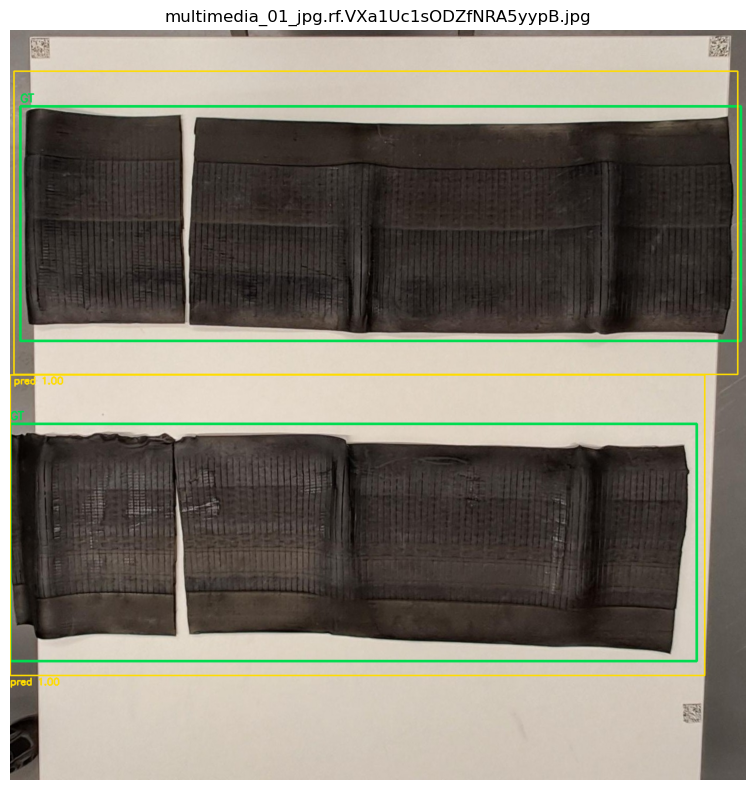

In [9]:
DATA_ROOT = Path("../data/new_samples_qr_rubber")

sample_img = sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))[0]
sample_lbl = DATA_ROOT / "train" / "labels" / (sample_img.stem + ".txt")

img_bgr = cv2.imread(str(sample_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

gt_boxes = load_gt_rubber(sample_lbl, W, H)
preds    = model(img_bgr, verbose=False, conf=CONF_THR)[0]

raw_preds  = [(b.xyxy[0], float(b.conf[0])) for b in preds.boxes if int(b.cls[0]) == RUBBER_CLASS]
raw_preds  = [p for p in raw_preds
              if (int(p[0][2])-int(p[0][0])) * (int(p[0][3])-int(p[0][1])) / (H * W) <= MAX_BOX_RATIO]
pred_boxes = [[*map(int, p[0])] for p in raw_preds]
pred_confs = [p[1] for p in raw_preds]

tp_ious, n_fp, n_fn = match_predictions(gt_boxes, pred_boxes)
print(f"GT rubber strips: {len(gt_boxes)}  |  Predichos: {len(pred_boxes)}")
print(f"TP: {len(tp_ious)}  FP: {n_fp}  FN: {n_fn}")
if tp_ious:
    print(f"IoU medio (TP): {np.mean(tp_ious):.3f}")

# diagnóstico: imprime IoU de cada predicción frente al GT más cercano
print("\n--- Diagnóstico IoU por predicción ---")
for pi, pred in enumerate(pred_boxes):
    ious = [bbox_iou(pred, gt) for gt in gt_boxes]
    print(f"  pred[{pi}] conf={pred_confs[pi]:.2f}  IoU_max={max(ious):.3f}  box={pred}")
print("--- GT boxes ---")
for gi, gt in enumerate(gt_boxes):
    print(f"  gt[{gi}]  box={[int(v) for v in gt]}")

overlay = img_rgb.copy()
for box in gt_boxes:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_GT, 3)
    cv2.putText(overlay, "GT", (x1, max(y1-8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, COLOR_GT, 2)
for box, conf in zip(pred_boxes, pred_confs):
    x1, y1, x2, y2 = box
    cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_PRED, 2)
    cv2.putText(overlay, f"pred {conf:.2f}", (x1, y2+18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_PRED, 2)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(overlay)
ax.set_title(sample_img.name)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Evaluación sobre todo el dataset (train + valid)

In [10]:
DATA_ROOT = Path("../data/new_samples_qr_rubber")

all_imgs = [
    (img, DATA_ROOT / "train" / "labels" / (img.stem + ".txt"))
    for img in sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))
] + [
    (img, DATA_ROOT / "valid" / "labels" / (img.stem + ".txt"))
    for img in sorted((DATA_ROOT / "valid" / "images").glob("*.jpg"))
]
print(f"Total imágenes: {len(all_imgs)}")

total_tp, total_fp, total_fn = 0, 0, 0
all_tp_ious = []
per_image   = []

for img_path, lbl_path in all_imgs:
    img_bgr    = cv2.imread(str(img_path))
    H, W       = img_bgr.shape[:2]
    gt_boxes   = load_gt_rubber(lbl_path, W, H)
    preds      = model(img_bgr, verbose=False, conf=CONF_THR)[0]
    pred_boxes = [[*map(int, b.xyxy[0])] for b in preds.boxes
                  if int(b.cls[0]) == RUBBER_CLASS
                  and (int(b.xyxy[0][2])-int(b.xyxy[0][0])) * (int(b.xyxy[0][3])-int(b.xyxy[0][1])) / (H * W) <= MAX_BOX_RATIO]

    tp_ious, n_fp, n_fn = match_predictions(gt_boxes, pred_boxes)
    total_tp += len(tp_ious)
    total_fp += n_fp
    total_fn += n_fn
    all_tp_ious.extend(tp_ious)

    per_image.append({
        "name":     img_path.name,
        "gt":       len(gt_boxes),
        "pred":     len(pred_boxes),
        "tp":       len(tp_ious),
        "fp":       n_fp,
        "fn":       n_fn,
        "iou_mean": np.mean(tp_ious) if tp_ious else None,
    })

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*55}")
print(f"TP: {total_tp}  FP: {total_fp}  FN: {total_fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")
if all_tp_ious:
    print(f"IoU medio (TP): {np.mean(all_tp_ious):.3f}")

print(f"\n{'Imagen':<50} {'GT':>4} {'Pred':>5} {'TP':>4} {'FP':>4} {'FN':>4} {'IoU':>6}")
print("-" * 80)
for r in per_image:
    iou_str = f"{r['iou_mean']:.3f}" if r["iou_mean"] is not None else "  — "
    print(f"{r['name']:<50} {r['gt']:>4} {r['pred']:>5} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} {iou_str:>6}")

Total imágenes: 22

TP: 44  FP: 9  FN: 0
Precision: 0.830
Recall:    1.000
F1:        0.907
IoU medio (TP): 0.836

Imagen                                               GT  Pred   TP   FP   FN    IoU
--------------------------------------------------------------------------------
multimedia_01_jpg.rf.VXa1Uc1sODZfNRA5yypB.jpg         2     2    2    0    0  0.771
multimedia_02_jpg.rf.Oj3RZ61LrtxiLIH6Q2qV.jpg         2     2    2    0    0  0.838
multimedia_04_jpg.rf.MGHdsSXWAqCvpoTV9eEz.jpg         2     2    2    0    0  0.846
multimedia_05_jpg.rf.UmwCstSbCbadDh62kdyj.jpg         2     3    2    1    0  0.840
multimedia_07_jpg.rf.rzxqe1IXC3fkfze6QTtc.jpg         2     2    2    0    0  0.943
multimedia_08_jpg.rf.Z7rzyNv5BaX4JsejH44T.jpg         2     3    2    1    0  0.864
multimedia_09_jpg.rf.4yp5FkHpPSDiJCr0gnE6.jpg         2     2    2    0    0  0.829
multimedia_10_jpg.rf.wxfQCr6OUG88R64iwuod.jpg         2     2    2    0    0  0.840
multimedia_11_jpg.rf.U2X6VMrXEcfhMHZ1Plqu.jpg   

## 5. Guardar visualizaciones

In [11]:
OUT_DIR = Path("outputs/figures/rubber_detection")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR = Path("../data/raw")
image_paths = sorted(RAW_DIR.glob("*.jpg"))
print(f"Imágenes a procesar: {len(image_paths)}")

for img_path in image_paths:
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W    = img_bgr.shape[:2]
    preds   = model(img_bgr, verbose=False, conf=CONF_THR)[0]

    raw_preds  = [(b.xyxy[0], float(b.conf[0])) for b in preds.boxes if int(b.cls[0]) == RUBBER_CLASS]
    raw_preds  = [p for p in raw_preds
                  if (int(p[0][2])-int(p[0][0])) * (int(p[0][3])-int(p[0][1])) / (H * W) <= MAX_BOX_RATIO]
    pred_boxes = [[*map(int, p[0])] for p in raw_preds]
    pred_confs = [p[1] for p in raw_preds]

    overlay = img_rgb.copy()
    for box, conf in zip(pred_boxes, pred_confs):
        x1, y1, x2, y2 = box
        cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_PRED, 2)
        cv2.putText(overlay, f"pred {conf:.2f}", (x1, max(y1-8, 14)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_PRED, 2)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(overlay)
    ax.set_title(img_path.name)
    ax.axis("off")
    plt.tight_layout()

    plt.savefig(OUT_DIR / img_path.name, dpi=100, bbox_inches="tight")
    plt.close()
    print(f"  {img_path.name} → {len(pred_boxes)} detecciones")

print(f"\nFiguras guardadas en: {OUT_DIR.resolve()}")

Imágenes a procesar: 22
  multimedia_01.jpg → 2 detecciones
  multimedia_02.jpg → 2 detecciones
  multimedia_03.jpg → 2 detecciones
  multimedia_04.jpg → 2 detecciones
  multimedia_05.jpg → 3 detecciones
  multimedia_06.jpg → 2 detecciones
  multimedia_07.jpg → 2 detecciones
  multimedia_08.jpg → 3 detecciones
  multimedia_09.jpg → 2 detecciones
  multimedia_10.jpg → 2 detecciones
  multimedia_11.jpg → 2 detecciones
  multimedia_12.jpg → 2 detecciones
  multimedia_13.jpg → 2 detecciones
  multimedia_14.jpg → 3 detecciones
  multimedia_15.jpg → 2 detecciones
  multimedia_16.jpg → 2 detecciones
  multimedia_17.jpg → 2 detecciones
  multimedia_18.jpg → 3 detecciones
  multimedia_19.jpg → 4 detecciones
  multimedia_20.jpg → 2 detecciones
  multimedia_21.jpg → 3 detecciones
  multimedia_22.jpg → 4 detecciones

Figuras guardadas en: C:\Users\jaime\Proyectos\VA_RetoMichelin\docs\4_models\GIDIA_VA_Proyect_Grupo1\models\Jaime\test\outputs\figures\rubber_detection


## 6. Exportar detecciones a JSON

Guarda los bboxes detectados sobre las imágenes raw en `../outputs/detections/rubber_detections.json`.
Este fichero es la entrada del notebook de segmentación EfficientSAM.

In [12]:
import json

RAW_DIR  = Path("../data/raw")
OUT_JSON = Path("outputs/detections/rubber_detections.json")
OUT_JSON.parent.mkdir(parents=True, exist_ok=True)

image_paths = sorted(RAW_DIR.glob("*.jpg"))
print(f"Imágenes a procesar: {len(image_paths)}")

detections = {}

for img_path in image_paths:
    img_bgr = cv2.imread(str(img_path))
    H, W    = img_bgr.shape[:2]
    preds   = model(img_bgr, verbose=False, conf=CONF_THR)[0]

    raw = [
        (b.xyxy[0], float(b.conf[0]))
        for b in preds.boxes
        if int(b.cls[0]) == RUBBER_CLASS
        and (int(b.xyxy[0][2])-int(b.xyxy[0][0])) * (int(b.xyxy[0][3])-int(b.xyxy[0][1])) / (H * W) <= MAX_BOX_RATIO
    ]
    raw = sorted(raw, key=lambda p: p[1], reverse=True)[:2]

    detections[img_path.name] = [
        {"bbox": [*map(int, box)], "conf": round(conf, 4)}
        for box, conf in raw
    ]
    print(f"  {img_path.name}: {len(detections[img_path.name])} detecciones")

OUT_JSON.write_text(json.dumps(detections, indent=2))
print(f"\nGuardado en: {OUT_JSON.resolve()}")

Imágenes a procesar: 22
  multimedia_01.jpg: 2 detecciones
  multimedia_02.jpg: 2 detecciones
  multimedia_03.jpg: 2 detecciones
  multimedia_04.jpg: 2 detecciones
  multimedia_05.jpg: 2 detecciones
  multimedia_06.jpg: 2 detecciones
  multimedia_07.jpg: 2 detecciones
  multimedia_08.jpg: 2 detecciones
  multimedia_09.jpg: 2 detecciones
  multimedia_10.jpg: 2 detecciones
  multimedia_11.jpg: 2 detecciones
  multimedia_12.jpg: 2 detecciones
  multimedia_13.jpg: 2 detecciones
  multimedia_14.jpg: 2 detecciones
  multimedia_15.jpg: 2 detecciones
  multimedia_16.jpg: 2 detecciones
  multimedia_17.jpg: 2 detecciones
  multimedia_18.jpg: 2 detecciones
  multimedia_19.jpg: 2 detecciones
  multimedia_20.jpg: 2 detecciones
  multimedia_21.jpg: 2 detecciones
  multimedia_22.jpg: 2 detecciones

Guardado en: C:\Users\jaime\Proyectos\VA_RetoMichelin\docs\4_models\GIDIA_VA_Proyect_Grupo1\models\Jaime\test\outputs\detections\rubber_detections.json
